# GeoBrain Flow Simulation Example

Oil-Water Two-Phase Reservoir Simulation.

Workflow:
1. Create reservoir model with ReservoirModel
2. Configure grid, rock, PVT, and relative permeability
3. Add production and injection wells
4. Run simulation with FlowPropagator
5. Visualize production curves and state maps

---

**Two-phase (oil–water) reservoir simulation** solves mass-conservation
equations for oil and water in porous media.  It is the core tool in
reservoir engineering for production forecasting and development planning.

This notebook uses a Newton–Raphson implicit solver with adaptive time
stepping.

In [1]:
import sys
sys.path.insert(0, '../..')

import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

from geobrain.physics.flow import ReservoirModel, FlowPropagator, Well, compute_well_index
from geobrain.vis import plot_field

## PVT & Relative Permeability

| Table | Description |
|-------|-------------|
| **PVDO** | Oil PVT: pressure → formation volume factor & viscosity |
| **PVTW** | Water PVT: same structure for water |
| **SWOF** | Relative permeability: water saturation → kr_w, kr_o, capillary pressure |

These tables describe fluid thermodynamics and multiphase flow behaviour.

In [2]:
# Load from JSON data file
_data_path = os.path.join("..", "data", "pvt", "pvt_data.json")
with open(_data_path) as _f:
    _pvt = json.load(_f)
PVDO = _pvt["PVDO"]["data"]
PVTW = _pvt["PVTW"]["data"]
SWOF = _pvt["SWOF"]["data"]

print(f'PVDO: {len(PVDO)} entries')
print(f'  Pressure range: {PVDO[0][0]:.1f} - {PVDO[-1][0]:.1f} psi')
print(f'PVTW: {len(PVTW)} entries')
print(f'SWOF: {len(SWOF)} entries')
print(f'  Sw range: {SWOF[0][0]:.1f} - {SWOF[-1][0]:.1f}')

PVDO: 42 entries
  Pressure range: 725.2 - 8982.1 psi
PVTW: 1 entries
SWOF: 10 entries
  Sw range: 0.0 - 1.0


## Model Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| Grid | 30 × 15 × 1 | 2-D areal model |
| Cell size | 50 × 50 × 20 ft | |
| Permeability | 200 mD | High-perm reservoir |
| Porosity | 0.2 | |
| Initial pressure | 6 000 psi | |
| Initial Sw | 0.1 | |
| Duration | 1 825 days (≈ 5 years) | |

In [3]:
# Simulation parameters
OPTIONS = {
    # Grid
    'nx': 30,
    'ny': 15,
    'nz': 1,
    'dx': 50.0,   # ft
    'dy': 50.0,   # ft
    'dz': 20.0,   # ft
    'd': 8000.0,  # Top depth (ft)

    # Rock properties
    'perm': 200.0,  # mD
    'poro': 0.2,

    # Initial conditions
    'po': 6000.0,   # Initial pressure (psi)
    'sw': 0.1,      # Initial water saturation

    # Time stepping
    'dt_init': 0.1,
    'dt_max': 50.0,
    't_end': 1825.0,  # 5 years

    # Solver
    'newton_tol': 1e-3,
    'max_newton_iter': 10,
}

print(f"Grid: {OPTIONS['nx']} x {OPTIONS['ny']} x {OPTIONS['nz']}")
print(f"Permeability: {OPTIONS['perm']} mD")
print(f"Porosity: {OPTIONS['poro']}")
print(f"Initial pressure: {OPTIONS['po']} psi")
print(f"Simulation time: {OPTIONS['t_end']} days ({OPTIONS['t_end']/365:.1f} years)")

Grid: 30 x 15 x 1
Permeability: 200.0 mD
Porosity: 0.2
Initial pressure: 6000.0 psi
Simulation time: 1825.0 days (5.0 years)


## Build the Reservoir Model

Construct a `ReservoirModel` step by step: grid → rock properties → PVT →
relative permeability.

In [4]:
print("\n--- Create Reservoir Model ---")

# Create model
model = ReservoirModel(
    nx=OPTIONS['nx'],
    ny=OPTIONS['ny'],
    nz=OPTIONS['nz']
)

# Set grid dimensions
model.set_grid(
    dx=OPTIONS['dx'],
    dy=OPTIONS['dy'],
    dz=OPTIONS['dz'],
    top_depth=OPTIONS['d']
)

# Set rock properties
model.set_rock(
    perm=OPTIONS['perm'],
    poro=OPTIONS['poro']
)

# Set PVT properties
model.set_pvt(
    pvdo=PVDO,
    pvtw=PVTW,
    rho_o_sc=45.0,   # Oil density at SC (lb/ft3)
    rho_w_sc=64.0    # Water density at SC (lb/ft3)
)

# Set relative permeability
model.set_relperm(swof=SWOF)

print(f"Model created: {model.nc} cells")


--- Create Reservoir Model ---
Model created: 450 cells


## Add Wells

Wells are connected to the grid through the **Peaceman well index**,
which accounts for grid-cell size, permeability, and wellbore radius:

| Well | Type | Location | BHP target |
|------|------|----------|-----------|
| P1 | Producer | (1, 1, 1) | 5 500 psi |
| I1 | Injector | (30, 15, 1) | 6 500 psi |

In [5]:
print("\n--- Add Wells ---")

def create_well(model, name, well_type, i, j, k, target, mode='BHP', rw=0.5, skin=0.0):
    """
    Create and configure a well with Peaceman well index.

    Args:
        model: ReservoirModel instance
        name: Well name (string)
        well_type: 'PROD' for producer, 'INJ' for injector
        i, j, k: Well location (1-based indices)
        target: Control target (BHP in psi, or rate in STB/day)
        mode: Control mode ('BHP' or 'RATE')
        rw: Well radius in ft (default: 0.5)
        skin: Skin factor (default: 0.0)

    Returns:
        Configured Well instance
    """
    well = Well(
        name=name,
        well_type=well_type,
        device=model.device,
        dtype=model.dtype
    )

    # Convert to 0-based index
    i0, j0, k0 = i - 1, j - 1, k - 1
    cell_idx = model.grid.ijk_to_global(i0, j0, k0)

    # Get cell properties for well index calculation
    dx = float(model.grid.dx[i0])
    dy = float(model.grid.dy[j0])
    dz = float(model.grid.dz[k0])
    kx = float(model.rock.perm_x[cell_idx])
    ky = float(model.rock.perm_y[cell_idx])

    # Compute well index using Peaceman formula
    wi = compute_well_index(kx, ky, dx, dy, dz, rw, skin)

    # Add perforation
    well.add_perforation(
        cell_idx=cell_idx,
        wi=wi,
        depth=model.grid.depth[cell_idx].item()
    )

    # Set control
    well.set_control(mode, target=target)

    return well

# Producer at corner (1, 1, 1)
p1 = create_well(model, 'P1', 'PROD', i=1, j=1, k=1, target=5500.0)
model.add_well(p1)

# Injector at opposite corner (30, 15, 1)
i1 = create_well(model, 'I1', 'INJ', i=30, j=15, k=1, target=6500.0)
model.add_well(i1)

print(f"Producer P1: BHP target = 5500 psi")
print(f"Injector I1: BHP target = 6500 psi")


--- Add Wells ---
Producer P1: BHP target = 5500 psi
Injector I1: BHP target = 6500 psi


## Initialise

Set uniform initial pressure and water saturation across all grid cells.

In [6]:
print("\n--- Initialize Model ---")

model.initialize(po=OPTIONS['po'], sw=OPTIONS['sw'])

print(f"Initial pressure: {OPTIONS['po']} psi")
print(f"Initial water saturation: {OPTIONS['sw']}")


--- Initialize Model ---
Initial pressure: 6000.0 psi
Initial water saturation: 0.1


## Run Simulation

`FlowPropagator` advances the simulation in time:

| Setting | Value | Purpose |
|---------|-------|---------|
| `dt_init` | 0.1 day | First time step (small for stability) |
| `dt_max` | 50 days | Maximum allowed step (adapts automatically) |
| `newton_tol` | 10⁻³ | Convergence tolerance per Newton step |
| `max_newton_iter` | 10 | Safety limit per time step |

In [7]:
print("\n--- Run Simulation ---")

propagator = FlowPropagator(
    model,
    dt_init=OPTIONS['dt_init'],
    dt_max=OPTIONS['dt_max'],
    max_newton_iter=OPTIONS['max_newton_iter'],
    newton_tol=OPTIONS['newton_tol']
)

print("Propagator created")
print(f"  dt_init: {OPTIONS['dt_init']} days")
print(f"  dt_max: {OPTIONS['dt_max']} days")
print(f"  Newton tolerance: {OPTIONS['newton_tol']}")

print(f"Running simulation to t={OPTIONS['t_end']} days...")

result = propagator(
    t_end=OPTIONS['t_end'],
    report_step=OPTIONS['t_end'] / 50,  # ~50 report steps
    verbose=True
)

print("Simulation complete!")


--- Run Simulation ---
Propagator created
  dt_init: 0.1 days
  dt_max: 50.0 days
  Newton tolerance: 0.001
Running simulation to t=1825.0 days...
Simulation complete!


## Extract Well Data

Retrieve time-series for each well: oil rate (ORAT), water rate (WRAT),
and bottomhole pressure (BHP).

In [8]:
print("\n--- Extract Results ---")

def get_well_data(result, well_name, field):
    """Extract well data from simulation result."""
    well_history = result.well_data[well_name]

    field_map = {
        'TIME': 'time',
        'ORAT': 'qo',
        'WRAT': 'qw',
        'BHP': 'bhp',
    }

    if field.upper() == 'LRAT':
        qo = np.array(well_history['qo'])
        qw = np.array(well_history['qw'])
        return qo + qw

    return np.array(well_history[field_map[field.upper()]])

# Extract well data
t = get_well_data(result, 'P1', 'TIME')
qo_p1 = get_well_data(result, 'P1', 'ORAT')
qw_p1 = get_well_data(result, 'P1', 'WRAT')
bhp_p1 = get_well_data(result, 'P1', 'BHP')

qw_i1 = get_well_data(result, 'I1', 'WRAT')
bhp_i1 = get_well_data(result, 'I1', 'BHP')

print(f"Number of report steps: {len(t)}")
print(f"Final time: {t[-1]:.1f} days")


--- Extract Results ---
Number of report steps: 63
Final time: 1825.0 days


## Production Curves

The most important reservoir-engineering output:

- **P1 oil rate**: observe the decline profile as reservoir pressure drops
- **I1 water injection rate**: the injector maintains reservoir energy


--- Visualization: Production Curves ---


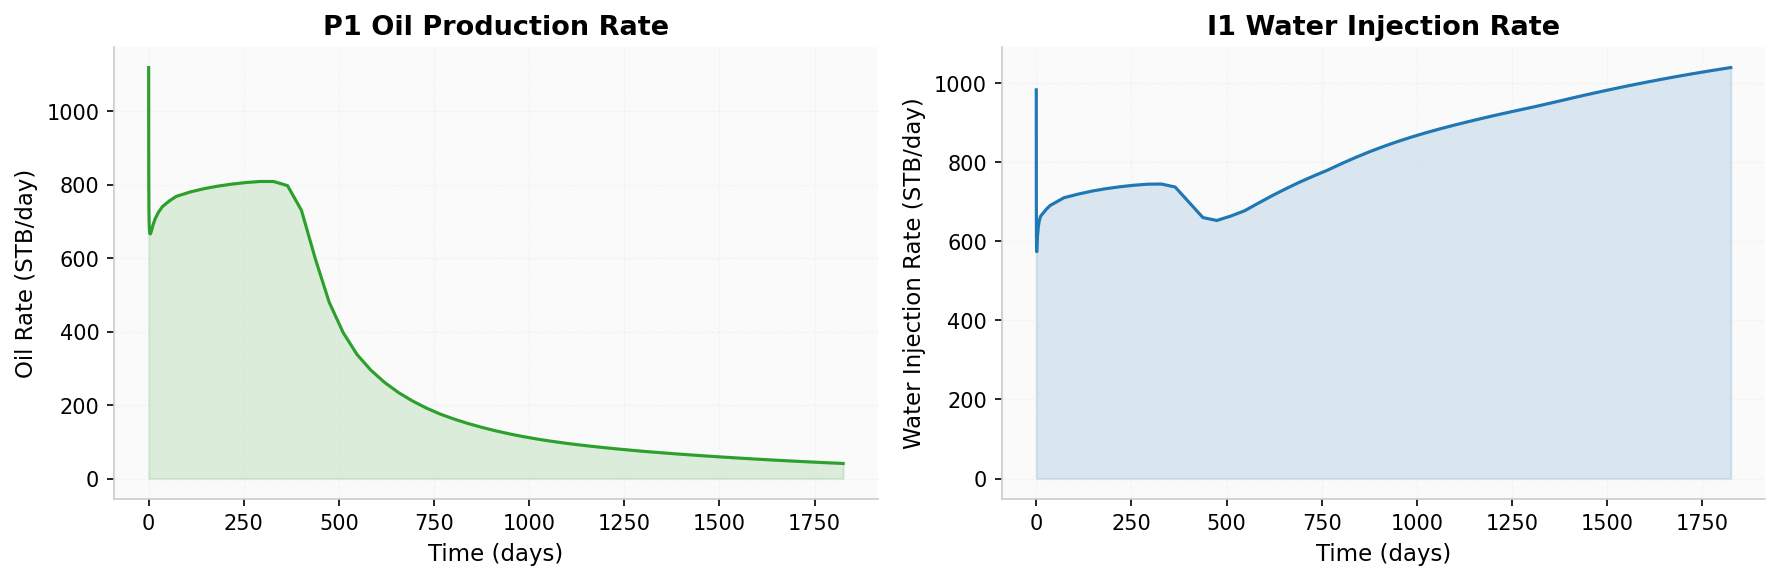

In [9]:
print("\n--- Visualization: Production Curves ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Oil rate
axes[0].fill_between(t, qo_p1, alpha=0.15, color='#2ca02c')
axes[0].plot(t, qo_p1, '-', color='#2ca02c', linewidth=1.5)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Oil Rate (STB/day)')
axes[0].set_title('P1 Oil Production Rate')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Water injection rate
qw_i1_pos = -np.array(qw_i1)
axes[1].fill_between(t, qw_i1_pos, alpha=0.15, color='#1f77b4')
axes[1].plot(t, qw_i1_pos, '-', color='#1f77b4', linewidth=1.5)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Water Injection Rate (STB/day)')
axes[1].set_title('I1 Water Injection Rate')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '10_production_curves.png'))
plt.show()

## Pressure & Saturation Maps

Final-state maps show:
- **Pressure**: high near the injector, low near the producer
- **Water saturation**: the waterflood front advancing from I1 toward P1


--- Visualization: State Maps ---


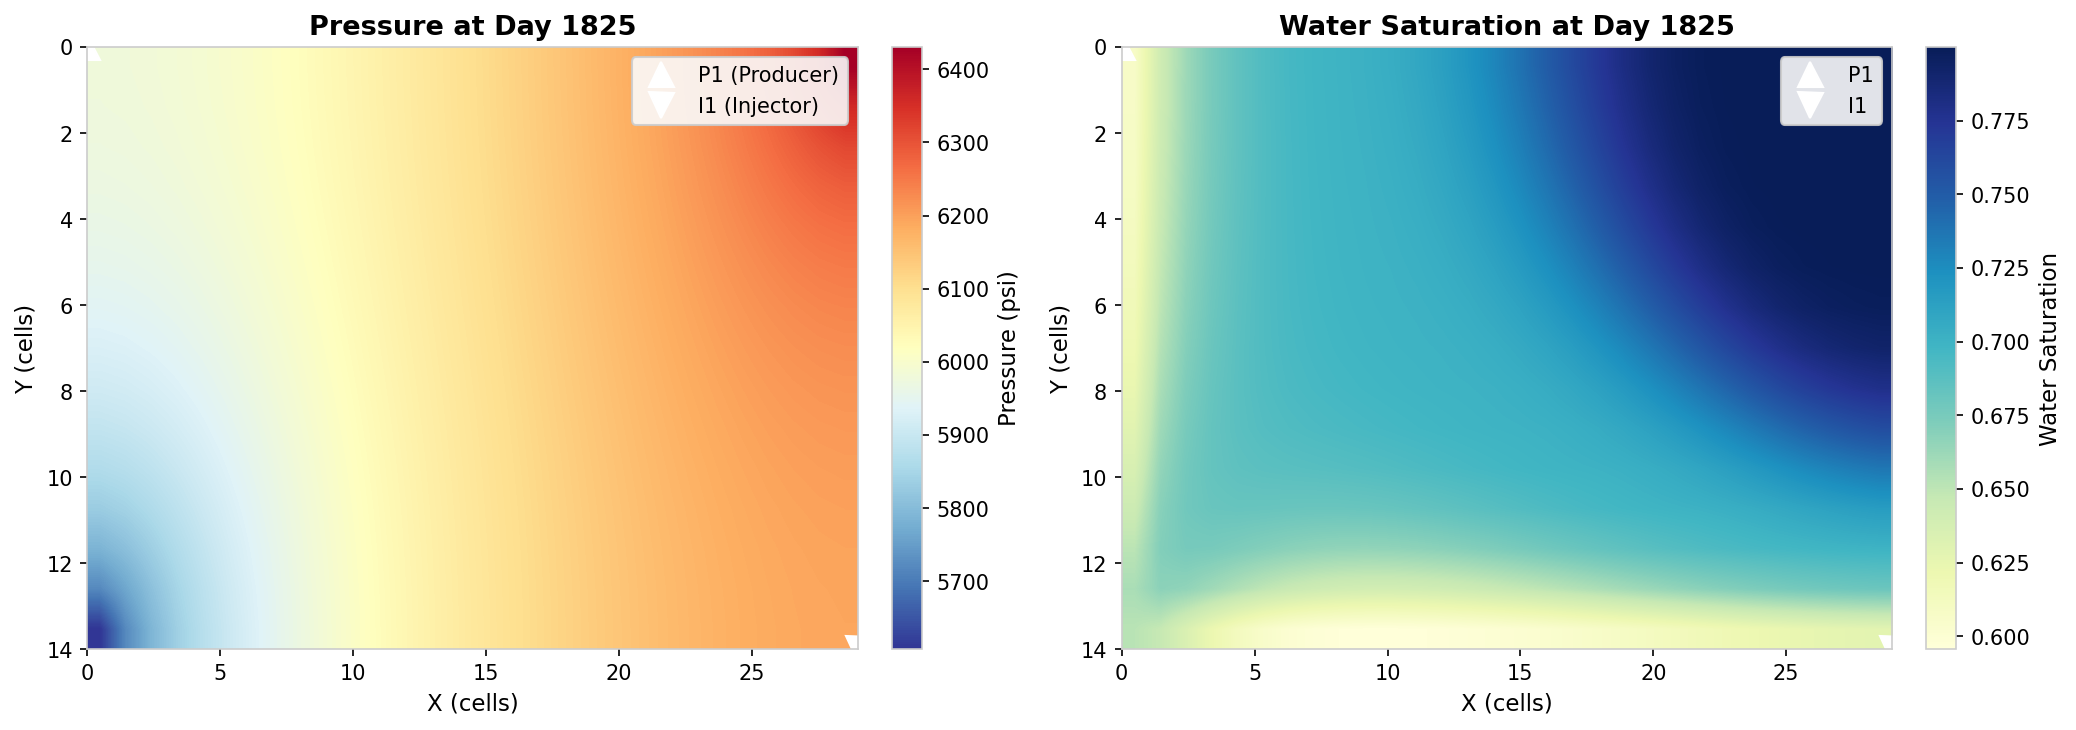

In [10]:
print("\n--- Visualization: State Maps ---")

# Get final state
po_final = result.pressure[-1].cpu().numpy()
sw_final = result.saturation[-1].cpu().numpy()

# Reshape to 2D
po_2d = po_final.reshape(model.ny, model.nx)
sw_2d = sw_final.reshape(model.ny, model.nx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pressure
plot_field(po_2d, ax=axes[0], cmap='RdYlBu_r', label='Pressure (psi)',
           origin='lower')
axes[0].set_title(f'Pressure at Day {t[-1]:.0f}')
axes[0].set_xlabel('X (cells)')
axes[0].set_ylabel('Y (cells)')
axes[0].plot(0, 0, 'w^', markersize=12, label='P1 (Producer)')
axes[0].plot(model.nx - 1, model.ny - 1, 'wv', markersize=12, label='I1 (Injector)')
axes[0].legend(loc='upper right')

# Water saturation
plot_field(sw_2d, ax=axes[1], cmap='YlGnBu', label='Water Saturation',
           origin='lower')
axes[1].set_title(f'Water Saturation at Day {t[-1]:.0f}')
axes[1].set_xlabel('X (cells)')
axes[1].set_ylabel('Y (cells)')
axes[1].plot(0, 0, 'w^', markersize=12, label='P1')
axes[1].plot(model.nx - 1, model.ny - 1, 'wv', markersize=12, label='I1')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '10_state_maps.png'))
plt.show()

## Animation

Time-lapse animation of pressure and water-saturation fields.  Key
snapshots at selected times reveal the waterflood-front progression.


--- Animation: Pressure & Saturation Evolution ---
Number of report steps (frames): 51
Animation saved to flow_simulation.gif


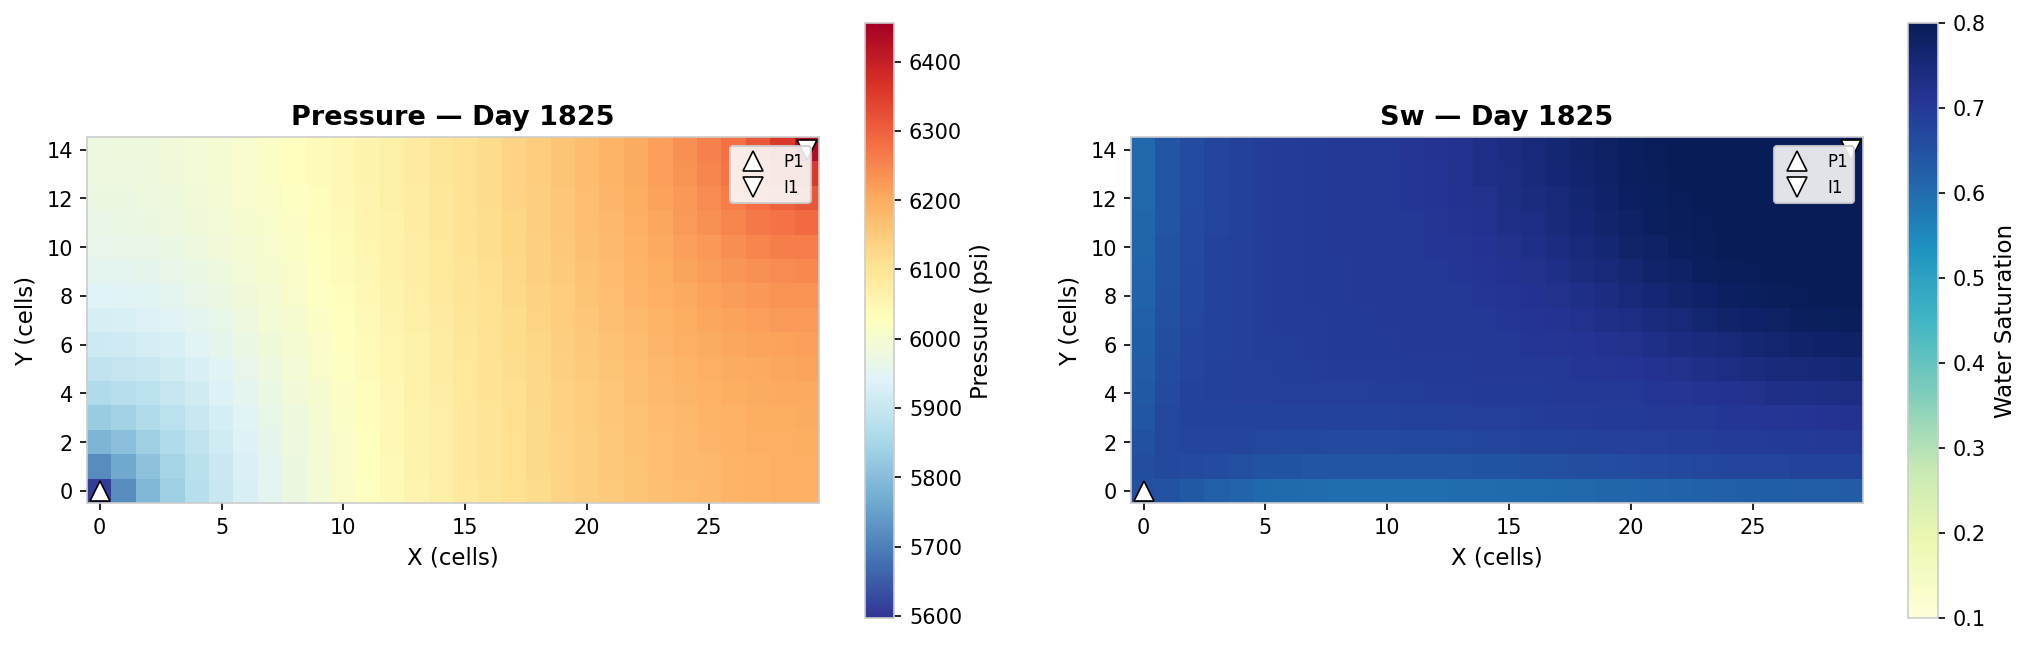

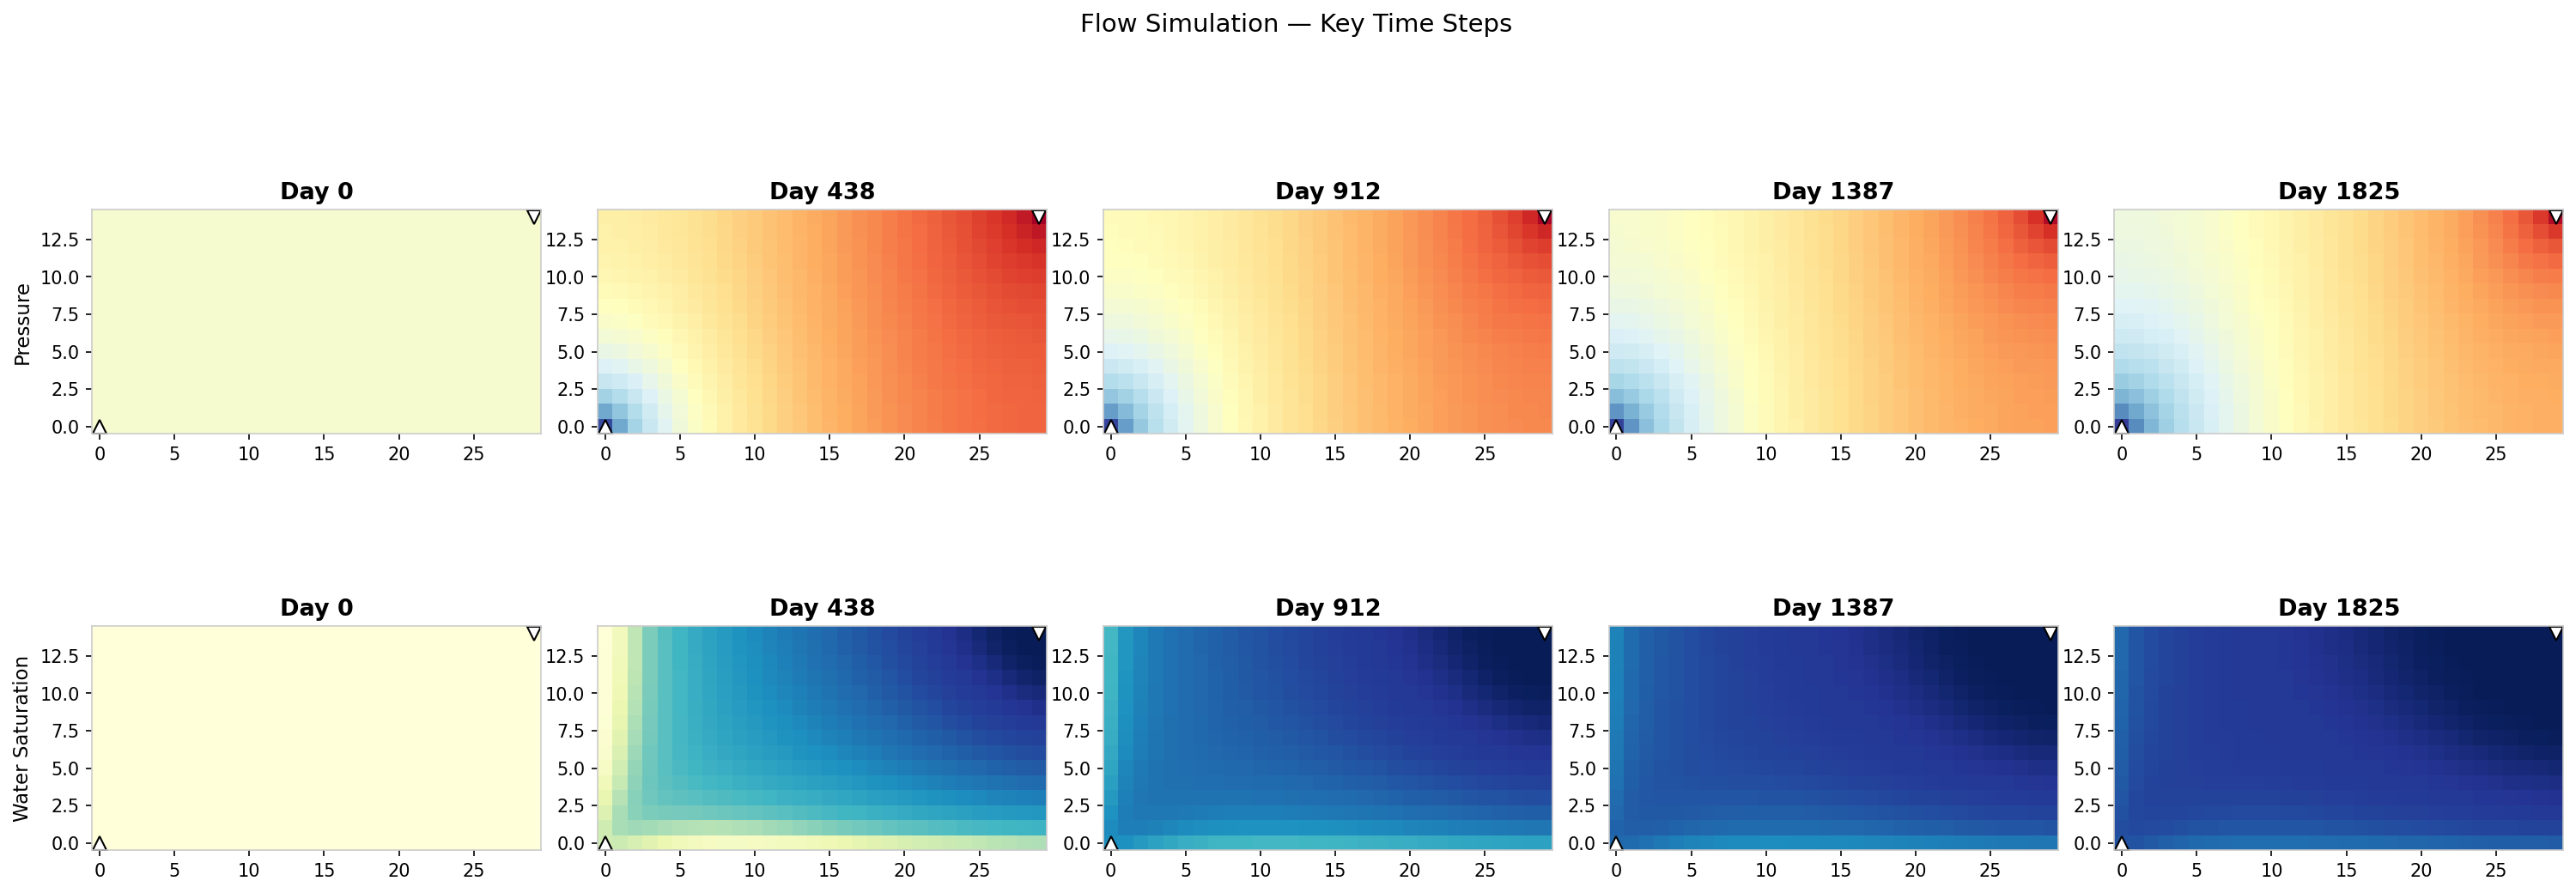

In [11]:
print("\n--- Animation: Pressure & Saturation Evolution ---")

from matplotlib.animation import FuncAnimation, PillowWriter

n_frames = len(result.time)
print(f"Number of report steps (frames): {n_frames}")

# Build arrays for all time steps
po_all = []
sw_all = []
for i in range(n_frames):
    po_i = result.pressure[i].cpu().numpy().reshape(model.ny, model.nx)
    sw_i = result.saturation[i].cpu().numpy().reshape(model.ny, model.nx)
    po_all.append(po_i)
    sw_all.append(sw_i)

po_all = np.array(po_all)  # (n_frames, ny, nx)
sw_all = np.array(sw_all)

# Global color ranges
po_min, po_max = po_all.min(), po_all.max()
sw_min, sw_max = sw_all.min(), sw_all.max()

# Well positions (cell indices)
p1_x, p1_y = 0, 0
i1_x, i1_y = model.nx - 1, model.ny - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(po_all[0], cmap='RdYlBu_r', origin='lower',
                  vmin=po_min, vmax=po_max)
ax1.plot(p1_x, p1_y, 'w^', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8, label='P1')
ax1.plot(i1_x, i1_y, 'wv', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8, label='I1')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_xlabel('X (cells)')
ax1.set_ylabel('Y (cells)')
plt.colorbar(im1, ax=ax1, label='Pressure (psi)', shrink=0.85)
title1 = ax1.set_title(f'Pressure — Day {result.time[0]:.0f}')

im2 = ax2.imshow(sw_all[0], cmap='YlGnBu', origin='lower',
                  vmin=sw_min, vmax=sw_max)
ax2.plot(p1_x, p1_y, 'w^', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8, label='P1')
ax2.plot(i1_x, i1_y, 'wv', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8, label='I1')
ax2.legend(loc='upper right', fontsize=8)
ax2.set_xlabel('X (cells)')
ax2.set_ylabel('Y (cells)')
plt.colorbar(im2, ax=ax2, label='Water Saturation', shrink=0.85)
title2 = ax2.set_title(f'Sw — Day {result.time[0]:.0f}')

plt.tight_layout()

def update_anim(frame):
    im1.set_data(po_all[frame])
    title1.set_text(f'Pressure — Day {result.time[frame]:.0f}')
    im2.set_data(sw_all[frame])
    title2.set_text(f'Sw — Day {result.time[frame]:.0f}')
    return [im1, im2, title1, title2]

anim = FuncAnimation(fig, update_anim, frames=n_frames, interval=150, blit=True)

gif_path = "flow_simulation.gif"
anim.save(gif_path, writer=PillowWriter(fps=8))
print(f"Animation saved to {gif_path}")
plt.show()

# Key time snapshots
key_idx = [0, n_frames // 4, n_frames // 2, 3 * n_frames // 4, n_frames - 1]
fig, axes = plt.subplots(2, len(key_idx), figsize=(4 * len(key_idx), 8))

for col, idx in enumerate(key_idx):
    # Pressure row
    axes[0, col].imshow(po_all[idx], cmap='RdYlBu_r', origin='lower',
                        vmin=po_min, vmax=po_max)
    axes[0, col].plot(p1_x, p1_y, 'w^', markersize=8, markeredgecolor='k')
    axes[0, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k')
    axes[0, col].set_title(f'Day {result.time[idx]:.0f}')
    if col == 0:
        axes[0, col].set_ylabel('Pressure')

    # Saturation row
    axes[1, col].imshow(sw_all[idx], cmap='YlGnBu', origin='lower',
                        vmin=sw_min, vmax=sw_max)
    axes[1, col].plot(p1_x, p1_y, 'w^', markersize=8, markeredgecolor='k')
    axes[1, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k')
    axes[1, col].set_title(f'Day {result.time[idx]:.0f}')
    if col == 0:
        axes[1, col].set_ylabel('Water Saturation')

plt.suptitle('Flow Simulation — Key Time Steps', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '10_key_time_steps.png'))
plt.show()